# Analisi esplorativa dei dati con *pandas*

## Caricamento dei dati

I file CSV possono essere ottenuti facilmente come export da qualsiasi ambiente e possono essere caricati facilmente in pandas.<br>
Anche SQLite 3 fornisce il modo per esportare una tabella nel formato csv. Vedi [questa chat](https://chatgpt.com/share/68494b60-2768-8012-9010-f0bd5dc434d9).

In [41]:
import pandas as pd

In [ ]:
pd.read_csv("export.csv")

Ora carichiamo il file CSV `CreditISLR` (un famoso dataset bancario costruito negli anni '90 da un professore universitario tedesco) in un dataframe pandas con tre errori voluti (tipici):

In [ ]:
df = pd.read_csv("CreditISLR.csv")    # il nome file è sbagliato

Verifichiamo la directory corrente con il comando magic `%pwd`

In [ ]:
%pwd

Verifichiamo i contenuti di questa directory con un altro comando magic:

In [ ]:
%ls

In [42]:
df = pd.read_csv("CreditISLR")        # manca il tipo file (.csv)

FileNotFoundError: [Errno 2] No such file or directory: 'CreditISLR'

Il terzo errore tipico è che il file NON è presente nella directory. Qui è presente!<br>
Il quarto errore tipico è omettere:
- il separatore usato nel file csv (`sep`) - in genere ma non sempre è la virgola (il default di `sep`), a volte è il punto e virgola, ed allora dobbiamo usare `sep=";"`
- oppure il booleano delle intestazioni (`header=None`) se il file csv NON contiene la prima riga delle intestazioni.

Per esemplificare questa situazione usiamo un file CSV che NON ha la riga di intestazioni:

In [44]:
nomi_colonne = ['Unnamed: 0','ID','Income','Limit','Rating','Cards','Age','Education','Gender','Student','Married','Ethnicity','Balance']
df = pd.read_csv("Credit_ISLR_no_header.csv", sep=",", header=None, names = nomi_colonne)

FileNotFoundError: [Errno 2] No such file or directory: 'Credit_ISLR_no_header.csv'

In [ ]:
df

Per finire, la lettura corretta:

In [45]:
df = pd.read_csv("Credit_ISLR.csv")

In [46]:
type(df)   # la classe dell'oggetto

pandas.core.frame.DataFrame

Le prime due colonne sono inutili e ridondanti e le possiamo eliminare con il metodo `drop` di *pandas* (il parametro `inplace` ha default `False`, se impostato a `True` la modifica alla struttura del database è definitiva (in memoria!!!)

In [47]:
df.drop(columns=['Unnamed: 0','ID'], inplace=True)

In [48]:
df

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331
...,...,...,...,...,...,...,...,...,...,...,...
395,12.096,4100,307,3,32,13,Male,No,Yes,Caucasian,560
396,13.364,3838,296,5,65,17,Male,No,No,African American,480
397,57.872,4171,321,5,67,12,Female,No,Yes,Caucasian,138
398,37.728,2525,192,1,44,13,Male,No,Yes,Caucasian,0


## Analisi esplorativa del dataset

In [ ]:
df.head()       # le prime n righe (n=5 per default)

In [ ]:
df.tail()        # le ultime n righe (n=5 per default)

Nella Data Science i dataset devono essere è [*tidy*](https://it.statisticseasily.com/glossario/cos%27%C3%A8-la-comprensione-dei-dati-ordinati-organizzazione-dei-dati/). Cioè:
- i clienti sono sulle righe e le colonne sono le loro caratteristiche
- non ci sono celle multi-valore (vedi un  esempio di cella multi-valore [qui](https://forum.knime.com/t/lookup-and-return-multiple-values-in-one-cell/65178))

*CreditISLR* è tidy.

In [ ]:
df.T    # dataset non tidy, non adatto alla Data Science

In [ ]:
# subsetting
display(df[:5])                # le prime 5 righe
display(df[5:])                # dalla riga 6 in poi

In [ ]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 100)
display(df[350:])                # dalla riga 350 in poi

In [ ]:
pd.reset_option('display.max_rows', 5)
pd.set_option('display.width', 5)

In [ ]:
df.info()      # fornisce parecchie info sul dataframe

In [ ]:
n=20
df.sample(n, random_state=10)     # seme = 10 (o qualsiasi altro valore numerico)

> Ogni volta che chiamiamo una funzione o un metodo che al suo interno ha un funzionamento casuale, possiamo RIPRODURRE ogni volta lo stesso comportamento casuale **impostando un seme**.

In [ ]:
df.isna()    # per controllare la presenza di valori mancanti nel dataset (na = not available)
             # questo metodo esegue un check booleano per ogni cella del dataframe: FALSE se la cella è valorizzata,
             # TRUE se il valore della cella è assente
             # l'output di questo metodo è una matrice booleana TRUE/FALSE

In [ ]:
import numpy as np          # un package che fornisce la funzione 'sum' (somma)
np.sum(df.isna(),axis=0)    # nei linguaggi di programmazione TRUE è memorizzato come 1 e FALSE come 0.
                            # axis = 0 --> la funzione 'sum' somma sulle colonne della matrice booleana

In [ ]:
np.sum(df['Income'].isna(),axis=0)     # subsetting, cioè estrarre un sottoinsieme di righe e/o di colonne dal dataframe

In [ ]:
df.columns      # i nomi delle colonne del dataframe:è un oggetto index (scomodo)

In [ ]:
list(df.columns) # trasformato in una lista

In [ ]:
df.shape        # fornisce le dimensioni del dataframe

In [ ]:
df.shape[0]     # fornisce solo il numero di righe

In [ ]:
df.size         # il numero totale delle celle del dataframe (il numero righe numero colonne

In [ ]:
df.dtypes       # gli 'bject' in pandas sono le stringhe alfanumeriche

In [ ]:
df.describe()   # le principali statistiche delle colonne numeriche

In [ ]:
round(df.describe(),2)     # per eliminare le cifre decimali dalla terza in poi

In [ ]:
display(df)         # per visualizzare un oggetto anche in celle di codice con diversi output

In [ ]:
df.select_dtypes('number')    # visualizza solo le colonne NUMERICHE

In [ ]:
df.select_dtypes('object')    # visualizza solo le colonne ALFANUMERICHE

In [ ]:
list(df['Ethnicity'].unique())   # la lista dei valori UNICI (utile per variabili alfanumeriche che hanno POCHI valori unici)

In [ ]:
df['Ethnicity'].value_counts()   # le frequenze (per una SPECIFICA colonna)

In [ ]:
pd.crosstab(index=df['Ethnicity'],columns=df['Age'])

In [ ]:
!conda install Jinja2 -y

In [ ]:
df.select_dtypes('number').style.map(lambda v: 'color: red' if v < 10 else '')     # 'map' applica una funzione lambda

All'inizio avevamo letto il file CSV con la funzione pandas `pd.read_csv`. Ora vogliamo salvare il nostro dataframe **su disco**.<br>
Non confondere la "persistenza" (un termine della OOP per intendere "salvataggio"):
- in memoria, tramite il parametro `inplace = True` fornito da alcuni metodi
- su disco, tramite un set di metodi della forma `to_XXX`

In [ ]:
display(df.select_dtypes('number').style.bar(color='lightblue'))
display(df.select_dtypes('number').style.bar(color='#d65f5f'))

In [ ]:
df.to_csv('df.csv')

In [ ]:
%ls

## Le serie

In pandas esistono anche le serie, costituite da una singola colonna di un certo data type elementare:

In [ ]:
s = pd.Series([10, 20, 30])
s

In [ ]:
type(s)

In [ ]:
# subsetting
s[0]

In [ ]:
# alcuni metodi dei dataframe sono disponibili anche per le serie
s.describe()

In [ ]:
s.info()

In [ ]:
s.shape

In [ ]:
s.head(2)

In [ ]:
s.tail(2)

## La standardizzazione dei dati
Diverse funzioni e metodi pandas devono lavorare su dati standardizzati, cioè centrati e riscalati.<br>

Vedi [questa buona voce](https://it.wikipedia.org/wiki/Standardizzazione_(statistica)) di Wikipedia.

I dati standardizzati perdono il loro significato originale ma sono confrontabili.<br>
Occorre avere installato sul PC o sulla macchina virtuale la libreria `scikit-learn`. Si può controllare da un terminale Anaconda con il comando `conda list` che elenca tutti i package / librerie installati 8con pip o conda):

In [49]:
# A maggio 2025 l'ultima è la 1.6.1.
import sklearn
print(sklearn.__version__)

1.6.1


In [50]:
from sklearn import preprocessing  # un package specifico per la pre-elaborazione dati (vari tipi tra i quali la standardizzazione)

In [51]:
std_array = preprocessing.scale(df.select_dtypes('number'))
                                           # la funzione 'scale' fa SIA centering CHE rescaling;
                                           # notare i 3 booleani a True per default.
                                           # usa uno stimatore BIASED della dev.std. Dall'help in linea, infatti:
                                           # "We use a biased estimator for the standard deviation, equivalent to
                                           # 'numpy.std(x, ddof=0). Note that the choice of 'ddof' is unlikely to
                                           # affect model performance."
                                           # la funzione 'scale' NON ha l'argomento 'ddof'!

display(std_array)                         # --> standardizzare significa prendere le SD come unità di misura.

array([[-0.86158299, -0.48999879, -0.46553881, ..., -1.2576741 ,
        -0.78492991, -0.40727698],
       [ 1.72743711,  0.82826106,  0.82870309, ...,  1.5284506 ,
         0.49658831,  0.83405596],
       [ 1.68675551,  1.01478681,  1.02931059, ...,  0.88996369,
        -0.78492991,  0.13063396],
       ...,
       [ 0.35946155, -0.24491264, -0.21963285, ...,  0.65778663,
        -0.46455035, -0.83194351],
       [-0.21280808, -0.95891584, -1.05441888, ..., -0.67723146,
        -0.1441708 , -1.13247675],
       [-0.75334493,  0.34199278,  0.38866085, ...,  0.48365384,
        -2.06644812,  0.97125591]])

In [53]:
df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [54]:
# check di un elemento (il primo della colonna 'Income':
(14.891 - df['Income'].mean())/ df['Income'].std()

np.float64(-0.8605053325388764)

L'errore tipico: applicare ad una array numpy un metodo pandas:

In [52]:
std_array.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

Molte elaborazioni in pandas, infatti, restituiscono una numpy array anche se l'input era un dataframe.
Dobbiamo convertire l'array numpy in un dataframe pandas

In [55]:
variabili = ['Income','Limit','Rating','Cards','Age','Education','Balance'] # le colonne numeriche standardizzate

In [56]:
std_df = pd.DataFrame(std_array,columns=variabili)  # per rimettere le colonne nel dataframe usiamo il parametro 'columns'
std_df

,Income,Limit,Rating,Cards,Age,Education,Balance
0,-0.861583,-0.489999,-0.465539,-0.699130,-1.257674,-0.784930,-0.407277
1,1.727437,0.828261,0.828703,0.031032,1.528451,0.496588,0.834056
2,1.686756,1.014787,1.029311,0.761194,0.889964,-0.784930,0.130634
3,2.946152,2.068440,2.110003,0.031032,-1.141586,-0.784930,0.966900
4,0.302928,0.070012,0.013331,-0.699130,0.715831,0.816968,-0.411633
...,...,...,...,...,...,...,...
395,-0.940986,-0.275711,-0.310230,0.031032,-1.373763,-0.144171,0.087078
396,-0.904963,-0.389362,-0.381413,1.491355,0.541698,1.137347,-0.087144
397,0.359462,-0.244913,-0.219633,1.491355,0.657787,-0.464550,-0.831944
398,-0.212808,-0.958916,-1.054419,-1.429291,-0.677231,-0.144171,-1.132477


A cosa servono i dati standardizzati? Ad esempio per poterli confrontare con un boxplot multiplo.<br>
Vediamo prima a single boxplot.

<Axes: >

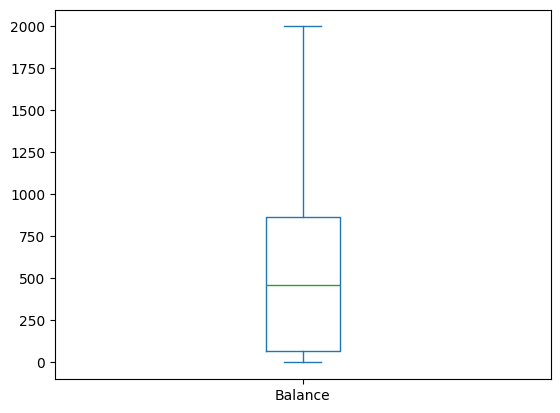

In [57]:
df['Balance'].plot.box()        # il boxplot della colonna 'Balance'

Il boxplot è la rappresentazione grafica del metodo `describe()`

In [ ]:
df['Balance'].describe()

Ora che abbiamo capito cosa è un boxplot, plottiamo un boxplot multiplo, cioè su tutte le colonne (numeriche) del dataframe, fianco a fianco:

<Axes: >

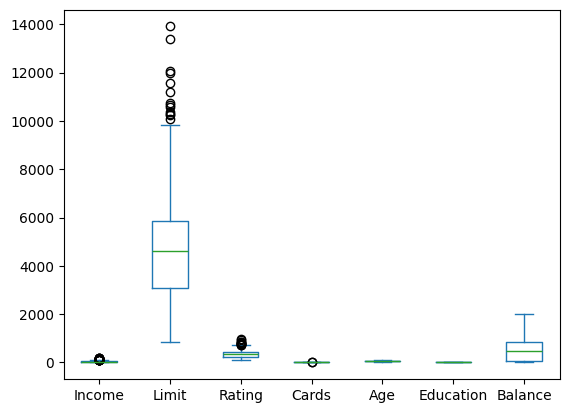

In [58]:
df.select_dtypes('number').plot.box()

In [ ]:
df.select_dtypes('number').describe()

<Axes: >

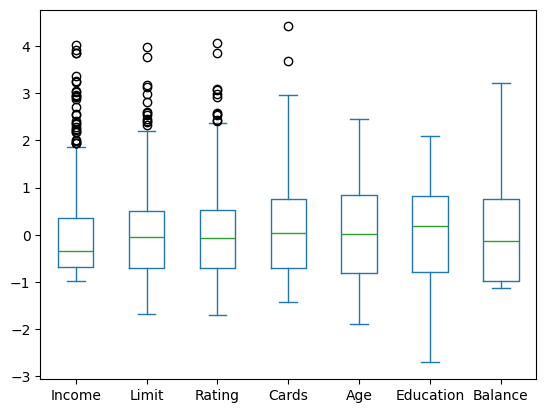

In [59]:
std_df.plot.box()

## Correlazione
La correlazione, un numero tra 0 ed 1 (se correlazione positiva) oppure tra 0 e -1 (se correlazione negativa), misura quanto due colonne numeriche del dataframe sono tra loro correlate,
- cioè se al crescere / diminuire di una, l'altra anche cresce / diminuisce (correlazione positive)
- esempio di correlazione positiva: prezzo e mq di un alloggio
- oppure se al crescere di una, l'altra diminuisce oppure l'opposto (correlazione negativa)
- esempio di correlazione negativa: prezzo e km di un'auto usata

La correlazione può essere calcolata anche sui dati NON standardizzati.

In [ ]:
df.select_dtypes('number').corr()

In [ ]:
df.corr(numeric_only=True)    # la stessa cosa

La precedente matrice ha TROPPA informazione. Dobbiamo semplificarla in due modi
- estranedo la matrice triangolare superiore (identica a quella inferiore, ma rovesciata)
- arrotondamento

In [ ]:
corr_matrix = df.corr(numeric_only=True)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

display(round(upper_tri,2))

Come regola pratica, le correlazioni > |0.7| sono interessanti. Non considerare le altre correlazioni, sono solo casualità (cioè esse dipendono da questo dataset)

## Plot

Uno dei plot più comuni è il grafico a dispersione (*scatter plot*) di due colonne:

In [ ]:
df.plot.scatter(x='Income',
                      y='Balance',
                      c='DarkBlue')

Vediamo la versione interattiva del plot, molto più comoda:

In [ ]:
!conda install -y altair

In [ ]:
import altair as alt
source = df    # 'source' è un comodo (per non rischiare di alterare 'df')

alt.Chart(source).mark_circle(size=60).encode(
    x='Income',
    y='Balance',
    color='Gender',
    tooltip=['Income', 'Balance', 'Age', 'Limit', 'Rating', 'Cards', 'Education']
).properties(
    width=800,   # oppure qualsiasi dimensione tu voglia
    height=600
).interactive()


Questo è lo scatterplot di UNA coppia di variabili. Per vedere tutti gli scatterplot dobbiamo plottare la *scatterplot matrix*:

In [ ]:
pd.plotting.scatter_matrix(df, figsize=(6,4))

Questa matrice di scatterplot è molto utile (SE le colonne NON sono troppe) per verificare facilmente ed in modo quasi automatico 2 cose:
- sono presenti outlier?
- ci sono trend tra le variabili?

In [ ]:
df['Balance'].hist()

In generale, i dati economici della clientela 'retail' come reddito, saldo, fatturato dei singoli clienti hanno una distribuzione fortemente assimmetrica (*skewed distribution*).<br>
Non la stessa cosa, in genere, per i dati socio-demografici.

In [ ]:
df['Age'].hist(bins=10)

<u>Quanti bins</u> dobbiamo chiedere? Due regole:
* da **5 a 20** (MAI BIN VUOTI): prof. Brandimarte (PoliTO)
* **1 + (10/3*log10(n))** (con n=num. osservazioni): prof.ssa Vicario (PoliTO) --> con n= 400 --> 1 + (10/3 * 3) = 10.

In [ ]:
n = df.shape[0]
1 + ((10/3) * np.log10(n))

In [ ]:
df['Balance'].plot.box()        # il boxplot della colonna 'Balance'

In [ ]:
df[['Balance','Income','Age']].plot.box()        # il boxplot della colonna 'Balance'

In [ ]:
df['Ethnicity'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6))

# Profiling automatico

In [ ]:
!pip install summarytools --user

In [ ]:
from summarytools import dfSummary

In [ ]:
dfSummary(df)

In [ ]:
!pip install skimpy --user

In [ ]:
from skimpy import skim

In [ ]:
skim(df)

# Numpy

## Cos'è NumPy e perché esiste

* Libreria per il calcolo numerico.
* Introduce il tipo ndarray, analogo delle liste ma omogeneo e molto efficiente.
* Pandas e scikit-learn sono costruiti sopra NumPy.

NumPy è l'infrastruttura sottostante.

In [2]:
!pip show numpy   # package già pre-installato.
                  # vedi le prime 10 righe.
                  # la versione è importante per possibili conflitti con altre package.
                  # come già detto più volte, google colab installa un insieme di (circa 650) package con versioni compatibili tra loro e con python, tuttavia,  se installiamo un NUOVO package (con !pip)è
                  # possibile un conflitto di versione con qualche package già installato o con la versione di python installata.

Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI

In [4]:
!python --version

Python 3.12.13


In [5]:
import numpy as np

**Il  tipo dati `ndarray`**

In [28]:
# definizione di una array molto semplice (1D): un vettore


a = np.array([10, 20, 30])   # la FUNZIONE (fornita da numpy) per creare array
                             # tra () i parametri della funzione, in questo caso i valori del vettore
                             # come si definisce IN PYTHON un vettore? con una LISTA! Come si definisce una lista in python? con le []

# ovviamente avremmo potuto scrivere questo codice equivalente:

lista = [10.2,20.3,30]
a = np.array(lista)

print(type(a))               # la funzione python type ci fornisce la classe alla quale un certo oggetto appartiene
print(a.shape)               # le dimensioni con le loro cardinalità.uno dei pochi metodi con lo stesso nome in pandas e in numpy
print(a.ndim)                # il numero di dimensioni (sino a 32, mi pare); in pandas esistono solo df bi-dimensionali e serie mono-dimensionali
print(a.dtype)               # il datatype elementare (omogeneo)
a

<class 'numpy.ndarray'>
(3,)
1
float64


array([10.2, 20.3, 30. ])

Tipico errore: creare una array eterogenea:

In [21]:
lista2 = [10,20,"pippo"]      # una lista Python può essere eterogenea (numeri, date, stringhe, booleani, ecc)
b = np.array(lista2)
b

array(['10', '20', 'pippo'], dtype='<U21')

Cosa è sucecsso? Siccome le array numpy devono essere omogenee (rispetto al datatype elementare)-tutti numeri, tutte stringhe, ecc - numpy ha trasformato tutto in stringhe.

Concetti:

* array monodimensionale e bidimensionale;
* shape;
* dtype.


**Valori mancanti**

In [29]:
print(np.nan)  # è un valore al quale possiamo impostare un elemento di una array
a[2] = np.nan
a

nan


array([10.2, 20.3,  nan])

Il subsetting di numpy è purtroppo differente dai subsetting di pandas.

**Alcune funzioni statistiche**

Compaiono spesso:

```python
    np.mean(b)
    np.median(b)
    np.std(b)
    np.min(b)
    np.max(b)
```


pandas possiede metodi equivalenti:

```python
    s.mean()
    s.std()
```

**Generazione di dati casuali**

Molto utile per esempi e machine learning:

In [37]:
# creiamo un oggetto "random number generator" (di nome rng)
rng = np.random.default_rng(100)          # seme di partenza, equivale al "random-state" di scikit-learn.
                                         # garantisce la riproducibilità dei risultati per qualsiasi esecuzione del notebook su qualsiasi maccchina

print(type(rng))

vet_std = rng.normal(size=100)           # un metodo della classe che genera un vettore di 100 numeri distribuiti in modo normale (gaussiano) standard
print(vet_std)

# check sulla distribuzione gaussiana standard
print(vet_std.mean())                    # la media è vicina a 0
print(vet_std.std())                     # dev std è vicina a 1
print(rng.integers(0, 10, size=20))      # un metodo della classe che genera un vettore di 20 numeri interi tra 0 e 10

<class 'numpy.random._generator.Generator'>
[-1.15754965  0.2897558   0.78085407  0.54397364 -0.96138264  1.07100867
  0.70145566  0.70497346  0.7450626   1.10434724  2.2429724  -0.61149312
  0.04721118  1.75423468 -1.33797987  0.32557447 -0.68911772 -0.01982181
  0.47475325 -1.93110142 -0.99247828 -1.40547108 -0.23109551 -0.68884708
  1.51510578 -0.60317155  1.71368449 -0.40624919  0.27140952  0.0398402
  0.01151832 -1.12717801  0.33471298  0.38389155  0.23783551  0.62141167
 -0.81924555 -0.29757921 -0.6615627  -1.70417033  0.36753632 -0.63548879
 -0.07772051  2.24976784  0.23031053  0.1074159   1.07394578  1.24635391
  1.8128927  -0.52148397  1.79593494 -0.1313578  -1.15822679 -0.92889132
  1.10784688  0.76254156  1.28252385 -0.92182446 -0.33978995 -1.19771712
 -1.97558574 -0.01806348  1.58269462  1.11208713 -0.77718527  1.16746978
 -0.57677824  0.31211181  0.82698919 -0.40758563 -0.88463743  0.64961265
 -0.17720308 -0.55183586  0.63429609 -0.21497068  0.3828658  -0.96560886
  0.7240

**Il ruolo di NumPy in scikit-learn**

Molti metodi e funzioni di scikit-learn restituiscono array:

In [ ]:
model.predict(X)
model.coef_
model.intercept_
preprocessing.scale(df)

Occorre saper riconoscere
```python
    type(pred)
    pred.shape
```

La funzione `scale`; come detto, essa restituisce una array numpy, che vogliamo ora esaminare meglio.

In [ ]:
std_array = preprocessing.scale(df.select_dtypes('number'))
                                           # la funzione 'scale' fa SIA centering CHE rescaling;
                                           # notare i 3 booleani a True per default.
                                           # usa uno stimatore BIASED della dev.std. Dall'help in linea, infatti:
                                           # "We use a biased estimator for the standard deviation, equivalent to
                                           # 'numpy.std(x, ddof=0). Note that the choice of 'ddof' is unlikely to
                                           # affect model performance."
                                           # la funzione 'scale' NON ha l'argomento 'ddof'!

display(std_array)                         # --> standardizzare significa prendere le SD come unità di misura.

In [60]:
type(std_array)

numpy.ndarray

In [61]:
std_array.shape

(400, 7)

In [62]:
std_array.T     # traspone le righe in colonne e le colonne in righe

array([[-0.86158299,  1.72743711,  1.68675551, ...,  0.35946155,
        -0.21280808, -0.75334493],
       [-0.48999879,  0.82826106,  1.01478681, ..., -0.24491264,
        -0.95891584,  0.34199278],
       [-0.46553881,  0.82870309,  1.02931059, ..., -0.21963285,
        -1.05441888,  0.38866085],
       ...,
       [-1.2576741 ,  1.5284506 ,  0.88996369, ...,  0.65778663,
        -0.67723146,  0.48365384],
       [-0.78492991,  0.49658831, -0.78492991, ..., -0.46455035,
        -0.1441708 , -2.06644812],
       [-0.40727698,  0.83405596,  0.13063396, ..., -0.83194351,
        -1.13247675,  0.97125591]])

Una operazione frequente è la conversione di un'array numpy in un dataframe o viceversa.

Cioè, come passare (convertire) da un dataframe pandas ad una array numpy (già visto al capitolo sulla standardizzazione dei dati) e viceversa (non ancora visto).

In [ ]:
# da array a dataframe:
pd.DataFrame(std_array,columns=variabili)

In [70]:
# da dataframe ad array (solo per le colonne numeriche):
df.select_dtypes('number').to_numpy()  # ad esempio, il valore di 'Income' del primo cliente (il cliente 0) è 14,891 (all'italiana)
                                       # il metodo pandas 'to_numpy' usa la notazione scientifica (disabilitabile) costituita da mantissa per esponente, qui:
                                       # mantissa: 1.48910
                                       # esponente in base 10: qui +1
                                       # cioè: 1.48910 x 10^1 = 14.891

array([[  14.891, 3606.   ,  283.   , ...,   34.   ,   11.   ,  333.   ],
       [ 106.025, 6645.   ,  483.   , ...,   82.   ,   15.   ,  903.   ],
       [ 104.593, 7075.   ,  514.   , ...,   71.   ,   11.   ,  580.   ],
       ...,
       [  57.872, 4171.   ,  321.   , ...,   67.   ,   12.   ,  138.   ],
       [  37.728, 2525.   ,  192.   , ...,   44.   ,   13.   ,    0.   ],
       [  18.701, 5524.   ,  415.   , ...,   64.   ,    7.   ,  966.   ]])

La array è visualizzata in notazione scientifica, cioè mantissa + esponente. Ad esempio:

In [66]:
1.48910 * np.power(10,1)

np.float64(14.891000000000002)

In [67]:
np.set_printoptions(precision=3) # imposta la precisione dell'output della mantissa (se tutte le cifre decimali danno fastidio)
print(std_array.mean(axis=0))

[ 0.000e+00 -1.599e-16  1.554e-17 -1.277e-17  1.776e-16  2.087e-16
  3.775e-17]


In [69]:
np.set_printoptions(suppress=True) # sopprime l'uso della notazione scientifica per piccoli numeri:
print(std_array.mean(axis=0))
std_array

[ 0. -0.  0. -0.  0.  0.  0.]


array([[-0.862, -0.49 , -0.466, ..., -1.258, -0.785, -0.407],
       [ 1.727,  0.828,  0.829, ...,  1.528,  0.497,  0.834],
       [ 1.687,  1.015,  1.029, ...,  0.89 , -0.785,  0.131],
       ...,
       [ 0.359, -0.245, -0.22 , ...,  0.658, -0.465, -0.832],
       [-0.213, -0.959, -1.054, ..., -0.677, -0.144, -1.132],
       [-0.753,  0.342,  0.389, ...,  0.484, -2.066,  0.971]])

Per ritornare alla notazione scientifica dobbiamo semplicemente impostare l'opzione precedente a FALSE

In [ ]:
np.set_printoptions(suppress=False) # sopprime l'uso della notazione scientifica per piccoli numeri:
print(std_array.mean(axis=0))

Occorre imparare a **convivere con NumPy**, perché pandas e scikit-learn lo usano continuamente anche quando non lo si utilizza esplicitamente.

Articolo sulla **matrice di covarianza** con *numpy* [qui](https://www.statology.org/how-to-calculate-and-interpret-the-covariance-matrix-with-numpy/?__s=o7u740my87lkp9nksy5d).